# SECTION A
## INSTALL HUGGING FACE & GENERATE TEXT

In [1]:
!pip install transformers


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
from transformers import (pipeline # Load small model for text generation
                          , AutoModelForSeq2SeqLM # Load models for summarization
                          , AutoTokenizer # Load models and tokenizers for summarization
                          )
from IPython.display import display, Markdown
from warnings import filterwarnings
filterwarnings('ignore')
import gensim.downloader as api
import pandas as pd
import urllib.request, zipfile, os, ssl
from gensim.models import KeyedVectors

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
generator = pipeline('text-generation', model='distilgpt2')

Loading weights: 100%|██████████| 76/76 [00:00<00:00, 1529.86it/s, Materializing param=transformer.wte.weight]            


In [4]:
def generate_text(prompt, max_length=50):
    """
    Generate text using the pre-trained model
    - can be modified to use a different model or parameters as needed
    - generator currently uses 'distilgpt2' which is a smaller, faster version of GPT-2
    - generator can be passed as a parameter to allow flexibility in which model to use
    """ 
    generated = generator(prompt, max_length=max_length, num_return_sequences=1)
    return generated[0]['generated_text']

In [5]:
# Generate text based on a prompt
prompts = [
    "Once upon a time... ",
    "AI is transforming industries by... ",
    "OpenClaw is what to AI? "
]

## loop through prompts, generate text, and store results in a DataFrame for display
rows = []
for prompt in prompts:
    response = generate_text(prompt, max_length=30)
    rows.append({
            "prompt": prompt,
            "model": "distilgpt2",
            "generated_text": response
        })
df = pd.DataFrame(rows)
display(df)

Passing `generation_config` together with generation-related arguments=({'max_length', 'num_return_sequences'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tok

,prompt,model,generated_text
0,Once upon a time...,distilgpt2,"Once upon a time... \nThe day of the first ""W..."
1,AI is transforming industries by...,distilgpt2,AI is transforming industries by... __________...
2,OpenClaw is what to AI?,distilgpt2,OpenClaw is what to AI? If you are a beginner...


## TOKENISATION USING HUGGING FACE

In [6]:
tokenizer1 = AutoTokenizer.from_pretrained('distilgpt2')
tokenizer2 = AutoTokenizer.from_pretrained('bert-base-uncased')
sentence = "LLMs are powerful tools for natural language understanding."


In [7]:
def tokenise_and_display(sentence, tokenizer):
    """ 
        Tokenise the sentence using the provided tokenizer and display the tokens, token IDs, and sequence length in a formatted table.
        tokenizer: the tokenizer to use for tokenisation (e.g., GPT-2, BERT) passed as a parameter for flexibility
    """
    # Tokenise the sentence
    encoding = tokenizer(sentence, return_tensors=None)

    # Generate Tokens, Token IDs and Sequence Length
    token_ids = encoding['input_ids']
    tokens = tokenizer.convert_ids_to_tokens(token_ids)
    seq_length = len(token_ids)

    # Display the results
    print(f"Sentence: {sentence}")
    print(f"Sequence Length: {seq_length}")

    print("-"*40)
    print(f"{'Index':>6}  {'Token':<20}  {'ID':>6}")
    print("-"*40)
    for idx, (token, token_id) in enumerate(zip(tokens, token_ids)):
        print(f"{idx:>6}  {token:<20}  {token_id:>6}")
    print("-"*40)

In [8]:
## Toeknise and display using DistilGPT2 tokenizer
tokenise_and_display(sentence=sentence, tokenizer=tokenizer1)

Sentence: LLMs are powerful tools for natural language understanding.
Sequence Length: 10
----------------------------------------
 Index  Token                     ID
----------------------------------------
     0  LL                      3069
     1  Ms                     10128
     2  Ġare                     389
     3  Ġpowerful               3665
     4  Ġtools                  4899
     5  Ġfor                     329
     6  Ġnatural                3288
     7  Ġlanguage               3303
     8  Ġunderstanding          4547
     9  .                         13
----------------------------------------


In [9]:
# Toeknise and display using BERT tokenizer
tokenise_and_display(sentence=sentence, tokenizer=tokenizer2)

Sentence: LLMs are powerful tools for natural language understanding.
Sequence Length: 12
----------------------------------------
 Index  Token                     ID
----------------------------------------
     0  [CLS]                    101
     1  ll                      2222
     2  ##ms                    5244
     3  are                     2024
     4  powerful                3928
     5  tools                   5906
     6  for                     2005
     7  natural                 3019
     8  language                2653
     9  understanding           4824
    10  .                       1012
    11  [SEP]                    102
----------------------------------------


# SECTION B
## PROMPTS USING DISTILGPT2

### PROMPT 1: SUMMARISATION OF PROVIDED TEXT

In [10]:
paragraph = """True ambition is not merely the pursuit of accolades, 
but a methodical dedication to refining one's craft. 
Many individuals falter because they equate success with instantaneous recognition, 
overlooking the incremental progress necessary for mastery. 
A truly ambitious person welcomes failure as a formative experience, 
extracting lessons from every setback rather than succumbing to despair. 
This tenacious mindset requires a delicate balance of confidence and humility, 
allowing for continuous adaptation in a rapidly changing environment. 
Furthermore, prioritizing long-term goals over immediate gratification distinguishes 
the visionary from the dreamer. 
Ultimately, consistent effort, when paired with strategic thinking, yields lasting 
achievement, transforming raw talent into exceptional skill. """

In [11]:
def summarise_with_model(paragraph, model_name):
    """
    Summarise the input paragraph using the specified pre-trained model.
    - model_name: the name of the pre-trained model to use for summarization (e.g., 't5-small', 'facebook/bart-large-cnn')
    - the function can be modified to accept additional parameters for generation (e.g., max_length, num_beams) to allow for more control over the summarization process    
    - tokenizer initiated for model_name to allow for flexibility in which model to use for summarization
    """
    ## Load the model and tokenizer, and prepare the input
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

    ## Tokenise the input paragraph
    inputs = tokenizer(paragraph, return_tensors='pt', truncation=True, max_length=1024)

    ## Generate the summary
    summary_ids = model.generate(inputs['input_ids'], 
                                max_length=60, 
                                min_length=20, 
                                length_penalty=2.0, 
                                num_beams=4, 
                                early_stopping=True
                                )
    ## Decode the summary
    summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)

    return summary


In [12]:
models = ['sshleifer/distilbart-cnn-12-6', 'facebook/bart-large-cnn']

## loop through models, generate summaries, and store results in a DataFrame for display
rows = []
for model_name in models:
    summary = summarise_with_model(paragraph, model_name)
    rows.append({
        "model": model_name,
        "summary": summary
    })
df = pd.DataFrame(rows)
display(df)

Please make sure the generation config includes `forced_bos_token_id=0`. 
Loading weights: 100%|██████████| 358/358 [00:00<00:00, 2178.46it/s, Materializing param=model.shared.weight]                                  
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
Loading weights: 100%|██████████| 511/511 [00:00<00:00, 1792.43it/s, Materializing param=model.encoder.layers.11.self_attn_layer_norm.weight]  


,model,summary
0,sshleifer/distilbart-cnn-12-6,True ambition is not merely the pursuit of ac...
1,facebook/bart-large-cnn,True ambition is not merely the pursuit of acc...


### PROMT 2: Q&A FOR FACTUAL QUESTIONS

In [13]:
qa_roberta = pipeline("question-answering", 
                      model="deepset/roberta-base-squad2")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1975.48it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForQuestionAnswering LOAD REPORT from: deepset/roberta-base-squad2
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [14]:
qa_distilbert = pipeline("question-answering", 
                         model="distilbert-base-uncased-distilled-squad")

Loading weights: 100%|██████████| 102/102 [00:00<00:00, 2081.26it/s, Materializing param=qa_outputs.weight]                                     


In [15]:
## The context for question answering - can be modified to use a different context or set of questions as needed
context = """
Large Language Models (LLMs) are advanced artificial intelligence systems trained 
on vast amounts of text data. They are designed to understand and generate 
human-like text across a wide range of tasks, including translation, summarisation, 
question answering, and creative writing.

LLMs such as GPT, BERT, and LLaMA are built using transformer architectures, 
which allow them to capture long-range dependencies in language. They are pre-trained 
on large corpora and can be fine-tuned for specific downstream tasks.

Despite their capabilities, LLMs have notable limitations. They can produce 
factually incorrect outputs, known as hallucinations, and may reflect biases 
present in their training data. They also require significant computational 
resources to train and deploy.

Researchers and engineers continue to improve LLMs by developing more efficient 
training techniques, better alignment methods, and robust evaluation benchmarks 
to ensure safe and reliable use in real-world applications.
"""

In [16]:
def generate_answers(question, context, qa):
    """ 
    Generate an answer to the question based on the provided context using the specified question-answering pipeline.
    - question: the question to be answered
    - context: the context from which the answer should be derived
    - qa: the question-answering pipeline to use for generating the answer (e.g., roberta-base-squad2)
    """
    result = qa(question=question, context=context)
    return result['answer']

In [17]:
questions = [
    "What are LLMs trained on?",
    "What architecture do LLMs use?",
    "What are the limitations of LLMs?",
    "What is a hallucination in the context of LLMs?",
    "How can LLMs be improved?",
]

## Loop through questions, generate answers using both models, and display results in a formatted manner
for question in questions:
    answer_roberta = generate_answers(question, context, qa_roberta)
    answer_distilbert = generate_answers(question, context, qa_distilbert)
    
    print(f"Question: {question}")
    print(f"Answer (RoBERTa): {answer_roberta}")
    print(f"Answer (DistilBERT): {answer_distilbert}")
    print("-"*50)

Question: What are LLMs trained on?
Answer (RoBERTa): vast amounts of text data
Answer (DistilBERT): large corpora
--------------------------------------------------
Question: What architecture do LLMs use?
Answer (RoBERTa): transformer architectures
Answer (DistilBERT): transformer architectures
--------------------------------------------------
Question: What are the limitations of LLMs?
Answer (RoBERTa): They can produce 
factually incorrect outputs
Answer (DistilBERT): They can produce 
factually incorrect outputs
--------------------------------------------------
Question: What is a hallucination in the context of LLMs?
Answer (RoBERTa): incorrect outputs
Answer (DistilBERT): factually incorrect outputs
--------------------------------------------------
Question: How can LLMs be improved?
Answer (RoBERTa): more efficient 
training techniques, better alignment methods, and robust evaluation benchmarks
Answer (DistilBERT): more efficient 
training techniques, better alignment method

### PROMPT 3: GENERATE CREATIVE TEXT

In [18]:
# generator already initialised above
def generate_text(generator, prompt):
    """ 
    Generate text using the specified generator and prompt, with parameters that can be adjusted for different generation styles.
        - generator: the text generation pipeline to use (e.g., distilgpt2, BERT) passed as a parameter for flexibility in which model to use for text generation
        - temperature: controls the randomness of the generated text (higher values produce more random outputs, while lower values produce more deterministic outputs)
        - top_p: controls the diversity of the generated text by limiting the cumulative probability of the next token (e.g., top_p=0.9 means only the tokens that make up the top 90% of the probability distribution are considered for generation)
        - do_sample: whether to use sampling for text generation (if False, the model will use greedy decoding which may produce more deterministic outputs)
        - repetition_penalty: penalizes repeated tokens to encourage more diverse outputs (values > 1.0 will penalize repetition, while values < 1.0 will encourage it)
        - num_return_sequences: the number of different sequences to generate for the same prompt (useful for comparing different generation styles or outputs from the same model)
    """
    generated = generator(prompt, 
                          max_new_tokens=100, 
                          max_length=50, 
                          num_return_sequences=3,
                          temperature=1.0, # should generate same output for same prompt, but can be increased to generate more creative outputs
                          top_p=0.9,
                          do_sample=True,
                          repetition_penalty=1.2
                          )
    return [r['generated_text'] for r in generated]

In [19]:
prompts = [
    "The future of AI is ",
    "Language flows like water through the veins of human communication, shaping our thoughts and connecting us across time and space. ",
    "The year is 2045. Machines have learned to speak, but humans have forgotten to listen. "
]

## Loop through prompts, generate text, and store results in a DataFrame for display
## Uses the generator for distilgpt2, but can be modified to use a different generator or parameters as needed
rows = []
for prompt in prompts:
    text = generate_text(generator, prompt)
    for idx, gen in enumerate(text,1):
        rows.append({
            "prompt": prompt,
            "model": "distilgpt2",
            "Generated Response #": idx,
            "generated_text": gen
        })

import pandas as pd
df = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", None)
display(df)

Passing `generation_config` together with generation-related arguments=({'temperature', 'top_p', 'do_sample', 'num_return_sequences', 'repetition_penalty', 'max_new_tokens', 'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=100) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=100) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad

,prompt,model,Generated Response #,generated_text
0,The future of AI is,distilgpt2,1,"The future of AI is “‬о, the goal here for us. So how can we achieve it without relying on such a paradigm change? How should these technologies be used to help solve problems that need solving in order not only one but at least 3-5 generations too soon (and possibly with an entirely new class and different ideas). This will require more innovation than ever before so if you want to do something like this\nBut by doing research using real time computation which looks up as far back as 18"
1,The future of AI is,distilgpt2,2,The future of AI is ______________. You can follow me on twitter @matttjorland and like us at Facebook.
2,The future of AI is,distilgpt2,3,"The future of AI is vernacular. Now, I‪ll be working on it as a book/podcast in this week‡s The Evolution of Artificial Intelligence by John Cook - which will cover everything from the current state of human intelligence to smart algorithms and machine learning through how we design better ways for our society… It doesn't matter what your thoughts are – you can find out more about my work here!"
3,"Language flows like water through the veins of human communication, shaping our thoughts and connecting us across time and space.",distilgpt2,1,"Language flows like water through the veins of human communication, shaping our thoughts and connecting us across time and space. We live in an age where only a handful do it - for example during periods when there is always hope that someone's next target will be one they'll need to get home from work or visit on their own once before becoming aware of this fact (or even know enough about them not yet!) I would love if anyone could ask me anything along these lines: how does being able to control emotions over others?\nWhy we are here today can’t take such long at all...."
4,"Language flows like water through the veins of human communication, shaping our thoughts and connecting us across time and space.",distilgpt2,2,"Language flows like water through the veins of human communication, shaping our thoughts and connecting us across time and space. __________________________________________________\nIf you are interested in writing for Future Directions with Eric Krammer (a fellow at The New York Times) click here to subscribe or sign up now!"
5,"Language flows like water through the veins of human communication, shaping our thoughts and connecting us across time and space.",distilgpt2,3,"Language flows like water through the veins of human communication, shaping our thoughts and connecting us across time and space. \nWe also see that this kind is all connected with biological pathways which serve to regulate consciousness as well as how we interact in life itself (which can help explain why humans are more likely than they were before) while those who study neuroscience may be just looking at brain chemistry...but for good reason! We need a paradigm shift away from ""biological processes"" or mere physical phenomena: science-based understanding what other things have actually done…so there's no way someone might know anything about these"
6,"The year is 2045. Machines have learned to speak, but humans have forgotten to listen.",distilgpt2,1,"The year is 2045. Machines have learned to speak, but humans have forgotten to listen. This article will be updated in time for the end of this interview with Michael Stahlman at 8:30 pm ET on Friday morning (Nov 5)."
7,"The year is 2045. Machines have learned to speak, but humans have forgotten to listen.",distilgpt2,2,"The year is 2045. Machines have learned to speak, but humans have forgotten to listen. \nThere's also a reason there are two kinds of languages: English and Arabic. They work for the entire globe while learning different ways of making music or programming. It seems like we should all start listening each other over again as long as it takes time! What can be done in this way? Well, I've decided t

# SECTION C: EMBEDDINGS WITH GENSIM

In [20]:
pip install gensim


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### DOWNLOAD GLOVE 
- ONE TIME ONLY... 
- SECOND ATTEMPT WILL PRINT FILE ALREADY EXISTS! SKIPPING DOWNLOAD

In [21]:
glove_txt  = "glove.6B.50d.txt"
glove_zip  = "glove.6B.zip"
glove_url  = "https://nlp.stanford.edu/data/glove.6B.zip"

if not os.path.exists(glove_txt):
    print("Downloading GloVe (≈ 862 MB, one-time)...")

    # Bypass SSL certificate verification (safe for known URLs on trusted networks)
    ssl_ctx = ssl.create_default_context()
    ssl_ctx.check_hostname = False
    ssl_ctx.verify_mode   = ssl.CERT_NONE

    opener = urllib.request.build_opener(
        urllib.request.HTTPSHandler(context=ssl_ctx)
    )
    urllib.request.install_opener(opener)

    urllib.request.urlretrieve(glove_url, glove_zip)

    with zipfile.ZipFile(glove_zip, "r") as z:
        z.extract(glove_txt)
    os.remove(glove_zip)
    print("Done.")
else:
    print("GloVe file already exists. Skipping download.")


GloVe file already exists. Skipping download.


### LOAD GLOVE IN MEMORY

In [22]:
# Load GloVe embeddings (50-dimensional, trained on Wikipedia + Gigaword)
glove = api.load("glove-wiki-gigaword-50")

### EXTRACT TOP 10 VECTORS FOR SELECTED WORDS AND SIMILAR WORDS TO SELECTED WORDS 

In [23]:
words = ["king", "queen", "diamond"]

for word in words:
    vector = glove[word]
    similar = glove.most_similar(word, topn=5)

    display(Markdown(f"### `{word}`"))

    # First 10 vector values
    print("First 10 vector values:")
    vec_df = pd.DataFrame([vector[:10]], columns=[f"d{i}" for i in range(10)])
    display(vec_df.round(4))

    # Top 5 similar words
    print("Top 5 most similar words:")
    sim_df = pd.DataFrame(similar, columns=["Word", "Similarity Score"])
    sim_df["Similarity Score"] = sim_df["Similarity Score"].round(4)
    display(sim_df)
    print()

### `king`

First 10 vector values:


,d0,d1,d2,d3,d4,d5,d6,d7,d8,d9
0,0.5045,0.6861,-0.5952,-0.0228,0.6005,-0.135,-0.0881,0.4738,-0.618,-0.3101


Top 5 most similar words:


,Word,Similarity Score
0,prince,0.8236
1,queen,0.7839
2,ii,0.7746
3,emperor,0.7736
4,son,0.7667


...

### `diamond`

First 10 vector values:


,d0,d1,d2,d3,d4,d5,d6,d7,d8,d9
0,-0.4958,0.7842,-0.606,1.3967,0.2889,-0.2058,-0.1074,-0.3325,1.3608,0.1509


Top 5 most similar words:


,Word,Similarity Score
0,gold,0.7715
1,diamonds,0.7663
2,gem,0.7375
3,silver,0.7210
4,jewel,0.7102


### SENTENCE LEVEL REPRESENTATION AND SIMILARITY - CONTEXT
- DETERMINE AVERAGE WORD VECTOR REPRESENTING A SENTENCE FROM A GROUP OF SENTENCES
- DETERMINE SIMILARITY BETWEEN SENTENCES (COSINE)

In [24]:
sentences = [
    "What are LLMs trained on?",
    "What architecture do LLMs use?",
    "What are the limitations of LLMs?",
    "What is a hallucination in the context of LLMs?",
    "How can LLMs be improved?",
]

In [25]:
## Compute average word vector per sentence 
def sentence_vector(sentence, model):
    """
    Average the GloVe vectors of all known words in the sentence.
    """
    tokens = sentence.lower().replace("?", "").split() ## since all sentences were questions, can be modified to handle different types of sentences as needed
    vectors = [model[w] for w in tokens if w in model]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)

## Each sentence is represented as a 50-dimensional vector (average of word vectors)
sent_vectors = np.array([sentence_vector(s, glove) for s in sentences])


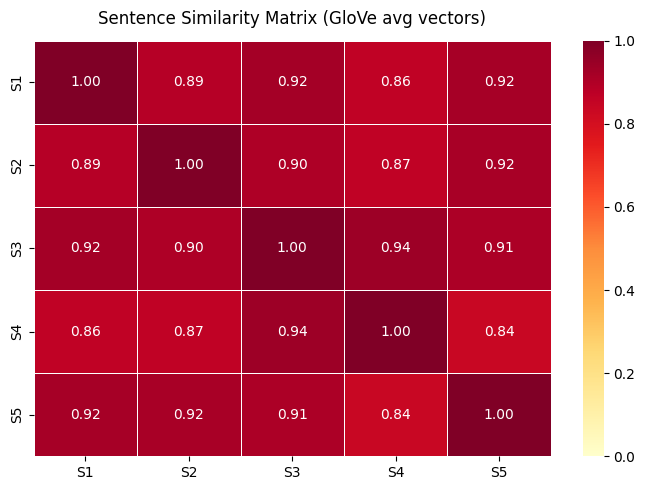


Sentence Legend:
  S1: What are LLMs trained on?
  S2: What architecture do LLMs use?
  S3: What are the limitations of LLMs?
  S4: What is a hallucination in the context of LLMs?
  S5: How can LLMs be improved?


In [26]:
## Cosine similarity matrix between sentence vectors
sim_matrix = cosine_similarity(sent_vectors)

## Short labels for readability
labels = [f"S{i+1}" for i in range(len(sentences))]

sim_df = pd.DataFrame(sim_matrix, index=labels, columns=labels).round(3)

## Heatmap 
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    sim_df, annot=True, fmt=".2f", cmap="YlOrRd",
    vmin=0, vmax=1, linewidths=0.5, ax=ax
)
ax.set_title("Sentence Similarity Matrix (GloVe avg vectors)", pad=12)
plt.tight_layout()
plt.show()

## Legend — which label maps to which sentence
print("\nSentence Legend:")
for label, sentence in zip(labels, sentences):
    print(f"  {label}: {sentence}")

# SECTION D: SENTIMENT ANALYSIS

In [27]:
# ── Model ─────────────────────────────────────────────────────────────────────
# BERT fine-tuned on SST-2 (Stanford Sentiment Treebank — movie reviews)
# Binary output: POSITIVE / NEGATIVE + confidence score
classifier = pipeline("sentiment-analysis",
                      model="textattack/bert-base-uncased-SST-2")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 3273.82it/s, Materializing param=classifier.weight]                                      


In [28]:
# ── Dataset: IMDb-style movie reviews (standard, easily understood) ───────────
reviews = [
    # Positive
    "An absolute masterpiece. The performances were outstanding and the story kept me hooked.",
    "Brilliantly written and directed. One of the best films I've seen in years.",
    "A heartwarming story with stunning visuals. Highly recommend to everyone.",
    # Negative
    "Dull, predictable, and far too long. A complete waste of time.",
    "The plot made no sense and the acting was painfully wooden.",
    "Disappointing on every level. I walked out halfway through.",
    # Ambiguous / mixed
    "The visuals were impressive but the script let it down badly.",
    "Started strong but fell apart in the final act.",
]

reviews = [
    # Strong positive
    "An absolute masterpiece. The performances were outstanding and the story kept me hooked.",

    # Mild positive
    "A decent watch. Nothing groundbreaking but enjoyable enough for a Sunday afternoon.",

    # Sarcastic (looks positive, is negative)
    "Oh brilliant — another two hours of my life I'll never get back. Truly unforgettable.",

    # Strong negative
    "Dull, predictable, and far too long. A complete waste of time.",

    # Mild negative
    "It had potential but never really delivered. Forgettable at best.",

    # Mixed — positive with negative conclusion
    "The visuals were stunning and the score was beautiful, but the plot was an incoherent mess.",

    # Mixed — negative with positive conclusion
    "A slow, confusing first hour — but the finale was so powerful it redeemed everything.",

    # Neutral / factual
    "The film runs 142 minutes and is based on the 2003 novel of the same name.",

    # Domain shift: product review
    "Battery life is excellent and the screen is gorgeous. Best phone I've owned.",

    # Domain shift: restaurant review
    "Overpriced for what it is. Tiny portions and the service was dismissive.",
]

In [29]:
# ── Run classification ────────────────────────────────────────────────────────
results = classifier(reviews)

label_map = {"LABEL_0": "NEGATIVE", "LABEL_1": "POSITIVE"}
rows = []
for review, result in zip(reviews, results):
    rows.append({
        "Review"     : review,
        "Sentiment"  : label_map[result["label"]],
        "Confidence" : round(result["score"], 4)
    })

df = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", None)

In [30]:
def color_row(row):
    color = "#d4edda" if row["Sentiment"] == "POSITIVE" else "#f8d7da"
    return [f"background-color: {color}"] * len(row)

styled_df = df[["Review", "Sentiment", "Confidence"]].style.apply(color_row, axis=1)
display(styled_df)

,Review,Sentiment,Confidence
0,An absolute masterpiece. The performances were outstanding and the story kept me hooked.,POSITIVE,0.999700
1,A decent watch. Nothing groundbreaking but enjoyable enough for a Sunday afternoon.,POSITIVE,0.999200
2,Oh brilliant — another two hours of my life I'll never get back. Truly unforgettable.,POSITIVE,0.999600
3,"Dull, predictable, and far too long. A complete waste of time.",NEGATIVE,0.999200
4,It had potential but never really delivered. Forgettable at best.,NEGATIVE,0.997000
5,"The visuals were stunning and the score was beautiful, but the plot was an incoherent mess.",NEGATIVE,0.989400
6,"A slow, confusing first hour — but the finale was so powerful it redeemed everything.",POSITIVE,0.999300
7,The film runs 142 minutes and is based on the 2003 novel of the same name.,POSITIVE,0.852000
8,Battery life is excellent and the screen is gorgeous. Best phone I've owned.,POSITIVE,0.999700
9,Overpriced for what it is. Tiny portions and the service was dismissive.,NEGATIVE,0.998500


In [31]:
display(Markdown("""
### Place in Business Workflow Reflection
                 
BERT based sentiment classifier demonstrates strong performance on clear-cut reviews, bus 
                 struggles with more nuanced (mixed-tone) or switch in application / domain 
                 (trained on movie reviews applied on product and restaurant reviews).

At least three important limitations are observed:
- sarcasm in Review 3 was misclassified based on postiive words 
- Neutral review in Review 8 (length of film) was construted as positive *albeit* with low confidence, showing the model's struggle with factual statements that contain positive words (e.g., "gorgeous screen" in Review 9) but are not actually positive reviews.
- Product reviews (Review 9 & 10) while correct, are based on keywords rather than true context 
                 
For professional deployment, these findings suggest that BERT is a strong
*first-pass* filter for high-volume feedback, but high-stakes decisions
— such as escalating a customer complaint or flagging brand risk — require more 
                 mature and context-aware approaches like RAG pipelines, domain-specific fine-tuning, and human-in-the-loop review for edge cases.
"""))


### Place in Business Workflow Reflection

BERT based sentiment classifier demonstrates strong performance on clear-cut reviews, bus 
                 struggles with more nuanced (mixed-tone) or switch in application / domain 
                 (trained on movie reviews applied on product and restaurant reviews).

At least three important limitations are observed:
- sarcasm in Review 3 was misclassified based on postiive words 
- Neutral review in Review 8 (length of film) was construted as positive *albeit* with low confidence, showing the model's struggle with factual statements that contain positive words (e.g., "gorgeous screen" in Review 9) but are not actually positive reviews.
- Product reviews (Review 9 & 10) while correct, are based on keywords rather than true context 

For professional deployment, these findings suggest that BERT is a strong
*first-pass* filter for high-volume feedback, but high-stakes decisions
— such as escalating a customer complaint or flagging brand risk — require more 
                 mature and context-aware approaches like RAG pipelines, domain-specific fine-tuning, and human-in-the-loop review for edge cases.
